# Cyclone Prediction – Machine Learning

This notebook:
1. Reads the cyclone dataset.
2. Performs preprocessing and stores the processed dataset.
3. Trains three classification algorithms, one algorithm per cell.
4. Saves confusion matrices and classification reports.
5. Compares model accuracy with a plot.
6. Saves the best-performing model.
7. Creates a standalone testing script that accepts each input using `input()` and predicts cyclone formation.

In [2]:
# Cell 1: Imports and configuration
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix
)

DATASET_PATH = "dataset.csv"

OUTPUT_DIR = "outputs"
MODEL_DIR = "saved_models"
PLOT_DIR = os.path.join(OUTPUT_DIR, "plots")
REPORT_DIR = os.path.join(OUTPUT_DIR, "reports")
PROCESSED_DIR = "processed_data"

for folder in [OUTPUT_DIR, MODEL_DIR, PLOT_DIR, REPORT_DIR, PROCESSED_DIR]:
    os.makedirs(folder, exist_ok=True)

print("Folders created successfully.")

Folders created successfully.


In [3]:
# Cell 2: Read dataset
df = pd.read_csv(DATASET_PATH)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isnull().sum())

Dataset shape: (2000, 10)

Columns:
['Sea_Surface_Temperature', 'Atmospheric_Pressure', 'Humidity', 'Wind_Shear', 'Vorticity', 'Latitude', 'Ocean_Depth', 'Proximity_to_Coastline', 'Pre_existing_Disturbance', 'Cyclone']

First 5 rows:


,Sea_Surface_Temperature,Atmospheric_Pressure,Humidity,Wind_Shear,Vorticity,Latitude,Ocean_Depth,Proximity_to_Coastline,Pre_existing_Disturbance,Cyclone
0,27.498160,1008.521429,89.279758,13.979877,0.000020,8.119890,76.137625,1.366176,1,1
1,28.404460,1001.242177,60.823380,19.548648,0.000084,9.246782,131.821235,0.683405,1,1
2,27.216969,995.742693,77.277801,9.368437,0.000063,7.789877,181.465092,0.866362,1,1
3,27.824280,1003.555279,67.986951,12.713517,0.000061,5.929008,323.395183,0.670524,1,1
4,26.260206,1008.466566,98.625281,17.125960,0.000034,6.953442,357.904862,0.940152,1,1



Data types:


Sea_Surface_Temperature     float64
Atmospheric_Pressure        float64
Humidity                    float64
Wind_Shear                  float64
Vorticity                   float64
Latitude                    float64
Ocean_Depth                 float64
Proximity_to_Coastline      float64
Pre_existing_Disturbance      int64
Cyclone                       int64
dtype: object


Missing values:


Sea_Surface_Temperature     0
Atmospheric_Pressure        0
Humidity                    0
Wind_Shear                  0
Vorticity                   0
Latitude                    0
Ocean_Depth                 0
Proximity_to_Coastline      0
Pre_existing_Disturbance    0
Cyclone                     0
dtype: int64

In [4]:
# Cell 3: Preprocessing
# Target column
TARGET_COLUMN = "Cyclone"

# Remove duplicate rows
df_processed = df.drop_duplicates().copy()

# Separate features and target
X = df_processed.drop(columns=[TARGET_COLUMN])
y = df_processed[TARGET_COLUMN]

# Handle missing numeric values using median
numeric_columns = X.select_dtypes(include=[np.number]).columns
X[numeric_columns] = X[numeric_columns].fillna(X[numeric_columns].median())

# Handle missing non-numeric values, if any
categorical_columns = X.select_dtypes(exclude=[np.number]).columns
for col in categorical_columns:
    X[col] = X[col].fillna(X[col].mode()[0])

# Ensure binary target is numeric
if y.dtype == "object":
    y = y.astype("category").cat.codes

# Store the processed dataset
processed_df = X.copy()
processed_df[TARGET_COLUMN] = y.values

processed_path = os.path.join(PROCESSED_DIR, "cyclone_processed.csv")
processed_df.to_csv(processed_path, index=False)

print("Processed dataset shape:", processed_df.shape)
print("Processed dataset saved to:", processed_path)
display(processed_df.head())

Processed dataset shape: (2000, 10)
Processed dataset saved to: processed_data\cyclone_processed.csv


,Sea_Surface_Temperature,Atmospheric_Pressure,Humidity,Wind_Shear,Vorticity,Latitude,Ocean_Depth,Proximity_to_Coastline,Pre_existing_Disturbance,Cyclone
0,27.498160,1008.521429,89.279758,13.979877,0.000020,8.119890,76.137625,1.366176,1,1
1,28.404460,1001.242177,60.823380,19.548648,0.000084,9.246782,131.821235,0.683405,1,1
2,27.216969,995.742693,77.277801,9.368437,0.000063,7.789877,181.465092,0.866362,1,1
3,27.824280,1003.555279,67.986951,12.713517,0.000061,5.929008,323.395183,0.670524,1,1
4,26.260206,1008.466566,98.625281,17.125960,0.000034,6.953442,357.904862,0.940152,1,1


In [5]:
# Cell 4: Train/test split and feature scaling
feature_columns = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Features:", feature_columns)
print("\nClass distribution:")
print(y.value_counts().sort_index())

Training samples: 1600
Testing samples: 400
Features: ['Sea_Surface_Temperature', 'Atmospheric_Pressure', 'Humidity', 'Wind_Shear', 'Vorticity', 'Latitude', 'Ocean_Depth', 'Proximity_to_Coastline', 'Pre_existing_Disturbance']

Class distribution:
Cyclone
0    1000
1    1000
Name: count, dtype: int64


Logistic Regression Accuracy: 100.0 %

Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       200
           1     1.0000    1.0000    1.0000       200

    accuracy                         1.0000       400
   macro avg     1.0000    1.0000    1.0000       400
weighted avg     1.0000    1.0000    1.0000       400



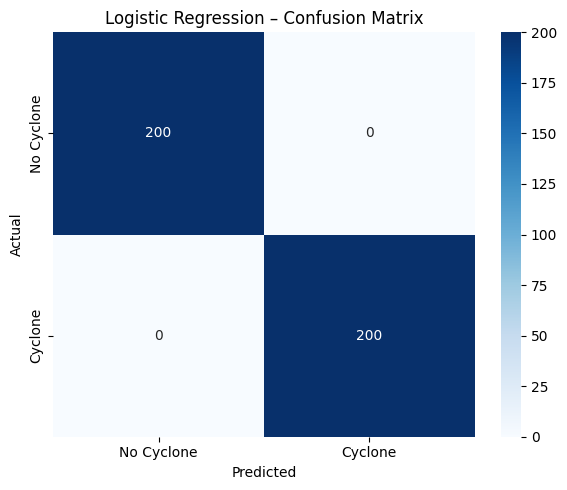

In [6]:
# Cell 5: Algorithm 1 – Logistic Regression
logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)
logistic_pred = logistic_model.predict(X_test_scaled)

logistic_accuracy = accuracy_score(y_test, logistic_pred)
logistic_cm = confusion_matrix(y_test, logistic_pred)

print("Logistic Regression Accuracy:", round(logistic_accuracy * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, logistic_pred, digits=4))

# Save confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(
    logistic_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Cyclone", "Cyclone"],
    yticklabels=["No Cyclone", "Cyclone"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression – Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "logistic_regression_confusion_matrix.png"), dpi=300)
plt.show()

# Save classification report
logistic_report = classification_report(y_test, logistic_pred, digits=4)
with open(os.path.join(REPORT_DIR, "logistic_regression_classification_report.txt"), "w") as f:
    f.write(logistic_report)

Random Forest Accuracy: 100.0 %

Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       200
           1     1.0000    1.0000    1.0000       200

    accuracy                         1.0000       400
   macro avg     1.0000    1.0000    1.0000       400
weighted avg     1.0000    1.0000    1.0000       400



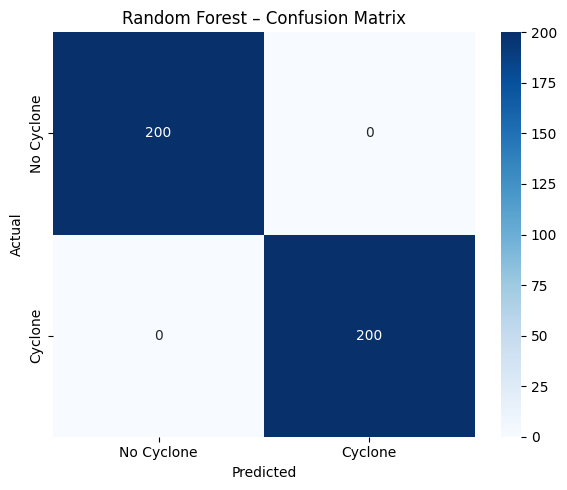

In [7]:
# Cell 6: Algorithm 2 – Random Forest
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(X_train, y_train)
random_forest_pred = random_forest_model.predict(X_test)

random_forest_accuracy = accuracy_score(y_test, random_forest_pred)
random_forest_cm = confusion_matrix(y_test, random_forest_pred)

print("Random Forest Accuracy:", round(random_forest_accuracy * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, random_forest_pred, digits=4))

# Save confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(
    random_forest_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Cyclone", "Cyclone"],
    yticklabels=["No Cyclone", "Cyclone"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest – Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "random_forest_confusion_matrix.png"), dpi=300)
plt.show()

# Save classification report
random_forest_report = classification_report(y_test, random_forest_pred, digits=4)
with open(os.path.join(REPORT_DIR, "random_forest_classification_report.txt"), "w") as f:
    f.write(random_forest_report)

SVM Accuracy: 100.0 %

Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       200
           1     1.0000    1.0000    1.0000       200

    accuracy                         1.0000       400
   macro avg     1.0000    1.0000    1.0000       400
weighted avg     1.0000    1.0000    1.0000       400



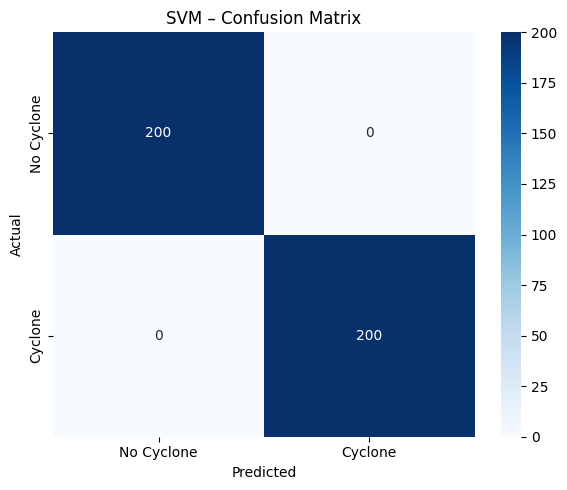

In [8]:
# Cell 7: Algorithm 3 – Support Vector Machine (SVM)
svm_model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)
svm_pred = svm_model.predict(X_test_scaled)

svm_accuracy = accuracy_score(y_test, svm_pred)
svm_cm = confusion_matrix(y_test, svm_pred)

print("SVM Accuracy:", round(svm_accuracy * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, svm_pred, digits=4))

# Save confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(
    svm_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Cyclone", "Cyclone"],
    yticklabels=["No Cyclone", "Cyclone"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM – Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "svm_confusion_matrix.png"), dpi=300)
plt.show()

# Save classification report
svm_report = classification_report(y_test, svm_pred, digits=4)
with open(os.path.join(REPORT_DIR, "svm_classification_report.txt"), "w") as f:
    f.write(svm_report)

,Algorithm,Accuracy,Accuracy_Percentage
0,Logistic Regression,1.0,100.0
1,Random Forest,1.0,100.0
2,SVM,1.0,100.0


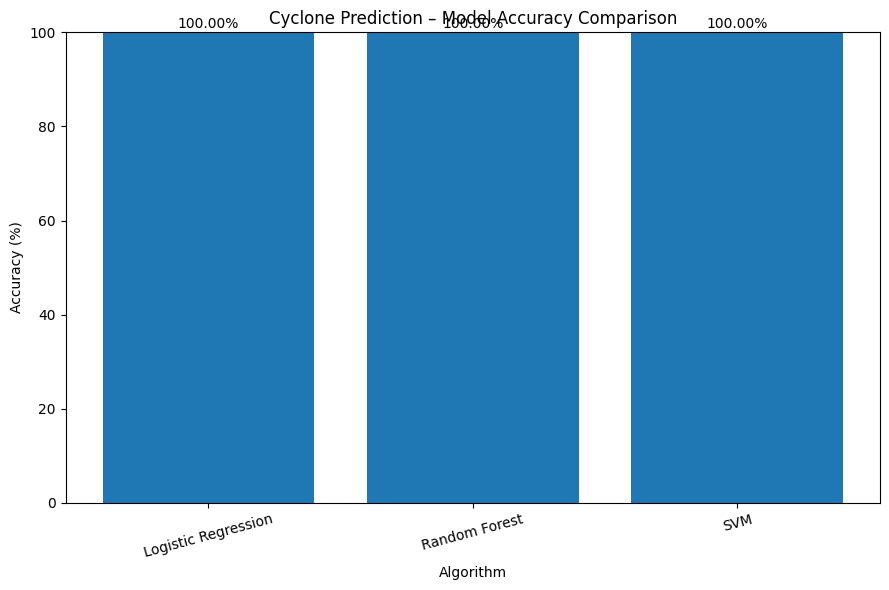

In [9]:
# Cell 8: Compare model accuracies
accuracy_results = pd.DataFrame({
    "Algorithm": [
        "Logistic Regression",
        "Random Forest",
        "SVM"
    ],
    "Accuracy": [
        logistic_accuracy,
        random_forest_accuracy,
        svm_accuracy
    ]
})

accuracy_results["Accuracy_Percentage"] = accuracy_results["Accuracy"] * 100

display(accuracy_results)

plt.figure(figsize=(9, 6))
bars = plt.bar(
    accuracy_results["Algorithm"],
    accuracy_results["Accuracy_Percentage"]
)

plt.ylabel("Accuracy (%)")
plt.xlabel("Algorithm")
plt.title("Cyclone Prediction – Model Accuracy Comparison")
plt.ylim(0, 100)
plt.xticks(rotation=15)

for bar, value in zip(bars, accuracy_results["Accuracy_Percentage"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
accuracy_plot_path = os.path.join(PLOT_DIR, "accuracy_comparison.png")
plt.savefig(accuracy_plot_path, dpi=300)
plt.show()

accuracy_results.to_csv(
    os.path.join(OUTPUT_DIR, "model_accuracy_comparison.csv"),
    index=False
)

In [10]:
# Cell 9: Select and store the best model
models = {
    "Logistic Regression": logistic_model,
    "Random Forest": random_forest_model,
    "SVM": svm_model
}

accuracies = {
    "Logistic Regression": logistic_accuracy,
    "Random Forest": random_forest_accuracy,
    "SVM": svm_accuracy
}

best_model_name = max(accuracies, key=accuracies.get)
best_model = models[best_model_name]
best_accuracy = accuracies[best_model_name]

# Random Forest does not require scaling, while Logistic Regression and SVM do.
uses_scaler = best_model_name in ["Logistic Regression", "SVM"]

model_package = {
    "model": best_model,
    "scaler": scaler if uses_scaler else None,
    "uses_scaled": uses_scaler,
    "feature_columns": feature_columns,
    "target_column": TARGET_COLUMN,
    "class_names": {
        0: "No Cyclone",
        1: "Cyclone"
    },
    "model_name": best_model_name,
    "accuracy": best_accuracy
}

best_model_path = os.path.join(MODEL_DIR, "best_cyclone_model.pkl")

with open(best_model_path, "wb") as f:
    pickle.dump(model_package, f)

print("Best model:", best_model_name)
print("Best accuracy:", round(best_accuracy * 100, 2), "%")
print("Saved model:", best_model_path)

Best model: Logistic Regression
Best accuracy: 100.0 %
Saved model: saved_models\best_cyclone_model.pkl


In [11]:
# Cell 10: Generate standalone testing script
testing_code = r'''
import pickle
import numpy as np
import pandas as pd

MODEL_PATH = "saved_models/best_cyclone_model.pkl"

with open(MODEL_PATH, "rb") as f:
    package = pickle.load(f)

model = package["model"]
scaler = package["scaler"]
uses_scaled = package["uses_scaled"]
feature_columns = package["feature_columns"]
class_names = package["class_names"]
model_name = package["model_name"]

print("=" * 60)
print("CYCLONE PREDICTION - STANDALONE TESTING")
print("=" * 60)
print("Loaded model:", model_name)
print("Enter the environmental parameters below.")

sea_surface_temperature = float(input("Sea Surface Temperature: "))
atmospheric_pressure = float(input("Atmospheric Pressure: "))
humidity = float(input("Humidity: "))
wind_shear = float(input("Wind Shear: "))
vorticity = float(input("Vorticity: "))
latitude = float(input("Latitude: "))
ocean_depth = float(input("Ocean Depth: "))
proximity_to_coastline = float(input("Proximity to Coastline: "))
pre_existing_disturbance = int(input("Pre-existing Disturbance (0=No, 1=Yes): "))

input_data = pd.DataFrame([{
    "Sea_Surface_Temperature": sea_surface_temperature,
    "Atmospheric_Pressure": atmospheric_pressure,
    "Humidity": humidity,
    "Wind_Shear": wind_shear,
    "Vorticity": vorticity,
    "Latitude": latitude,
    "Ocean_Depth": ocean_depth,
    "Proximity_to_Coastline": proximity_to_coastline,
    "Pre_existing_Disturbance": pre_existing_disturbance
}])

input_data = input_data[feature_columns]

if uses_scaled:
    model_input = scaler.transform(input_data)
else:
    model_input = input_data

prediction = model.predict(model_input)[0]

if hasattr(model, "predict_proba"):
    probability = model.predict_proba(model_input)[0]
    confidence = float(np.max(probability)) * 100
else:
    confidence = None

result = class_names.get(int(prediction), str(prediction))

print("\n" + "=" * 60)
print("PREDICTION RESULT")
print("=" * 60)
print("Prediction:", result)

if confidence is not None:
    print(f"Confidence: {confidence:.2f}%")

if int(prediction) == 1:
    print("Cyclone formation is predicted.")
else:
    print("No cyclone formation is predicted.")
print("=" * 60)
'''

with open("standalone_cyclone_test.py", "w", encoding="utf-8") as f:
    f.write(testing_code)

print("Created standalone_cyclone_test.py")

Created standalone_cyclone_test.py


## Output files

After running all cells, the project will contain:

- `processed_data/cyclone_processed.csv` – processed dataset
- `outputs/plots/` – three confusion matrices and accuracy comparison plot
- `outputs/reports/` – three classification reports
- `outputs/model_accuracy_comparison.csv` – accuracy table
- `saved_models/best_cyclone_model.pkl` – best model package
- `standalone_cyclone_test.py` – standalone prediction program

### Required packages

```bash
pip install pandas numpy scikit-learn matplotlib seaborn jupyter
```

Run the standalone tester from the project directory:

```bash
python standalone_cyclone_test.py
```